In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


## EDA

In [7]:
df = pd.read_csv("D:\\Python Data Projects\\Stock Market Prediction\\NVidia_stock_history.csv")
df.columns = df.columns.str.strip()
df.shape

(6847, 7)

In [8]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037603,0.041016,0.048828,0.038802,0.043750,2714688000
1,1999-01-25,0.041542,0.045313,0.045833,0.041016,0.044271,510480000
2,1999-01-26,0.038319,0.041797,0.046745,0.041146,0.045833,343200000
3,1999-01-27,0.038200,0.041667,0.042969,0.039583,0.041927,244368000
4,1999-01-28,0.038080,0.041536,0.041927,0.041276,0.041667,227520000


In [9]:
df.info() # No Null values :)

<class 'pandas.DataFrame'>
RangeIndex: 6847 entries, 0 to 6846
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6847 non-null   str    
 1   Adj Close  6847 non-null   float64
 2   Close      6847 non-null   float64
 3   High       6847 non-null   float64
 4   Low        6847 non-null   float64
 5   Open       6847 non-null   float64
 6   Volume     6847 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 374.6 KB


In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.sort_index()


In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6847 entries, 1999-01-22 to 2026-04-13
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  6847 non-null   float64
 1   Close      6847 non-null   float64
 2   High       6847 non-null   float64
 3   Low        6847 non-null   float64
 4   Open       6847 non-null   float64
 5   Volume     6847 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 374.4 KB


In [12]:
df_dup = df.duplicated()
cnt = df_dup.sum()
print(cnt)

0


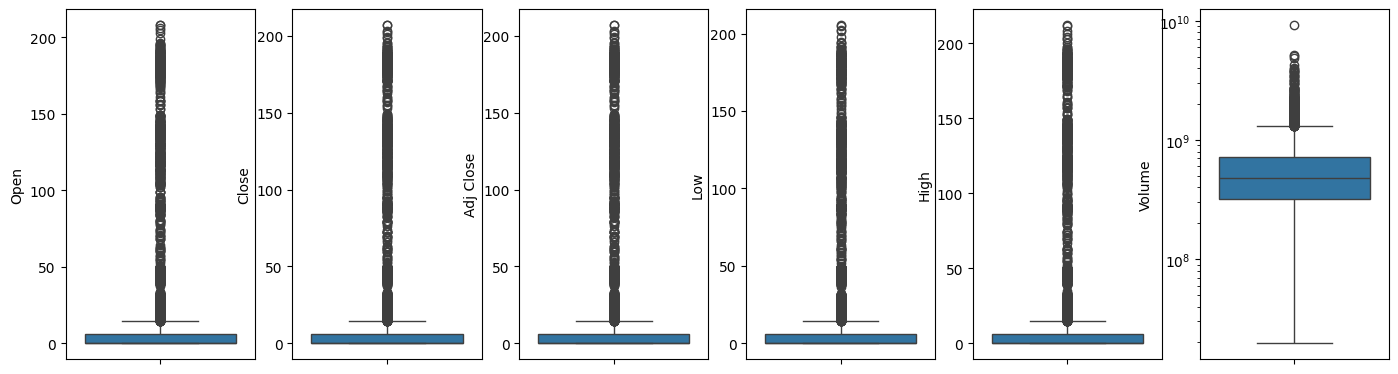

In [13]:
features = ['Open', 'Close', 'Adj Close', 'Low', 'High', 'Volume' ]

plt.figure(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,7,i+1)
  sns.boxplot(df[col])
plt.yscale("log") 
plt.show()

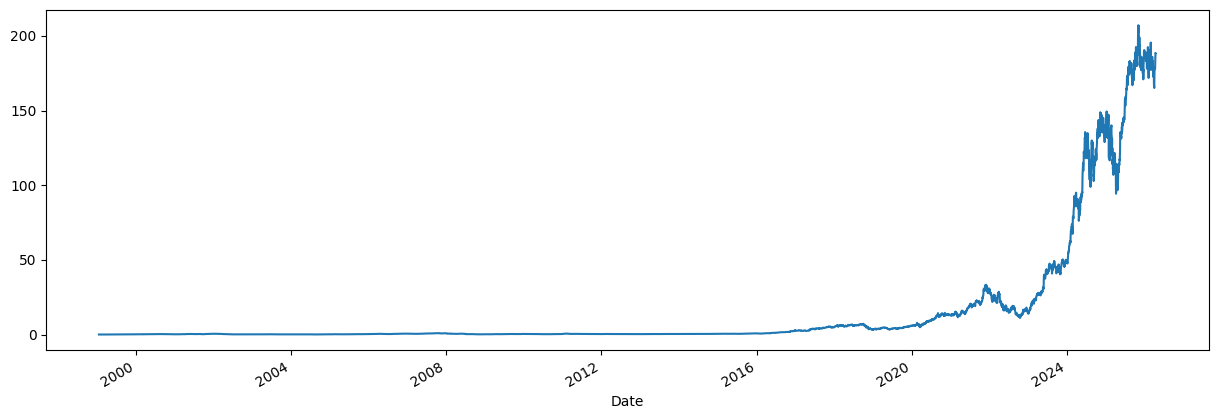

In [14]:
df['Close'].plot(figsize=(15,5))
plt.show()

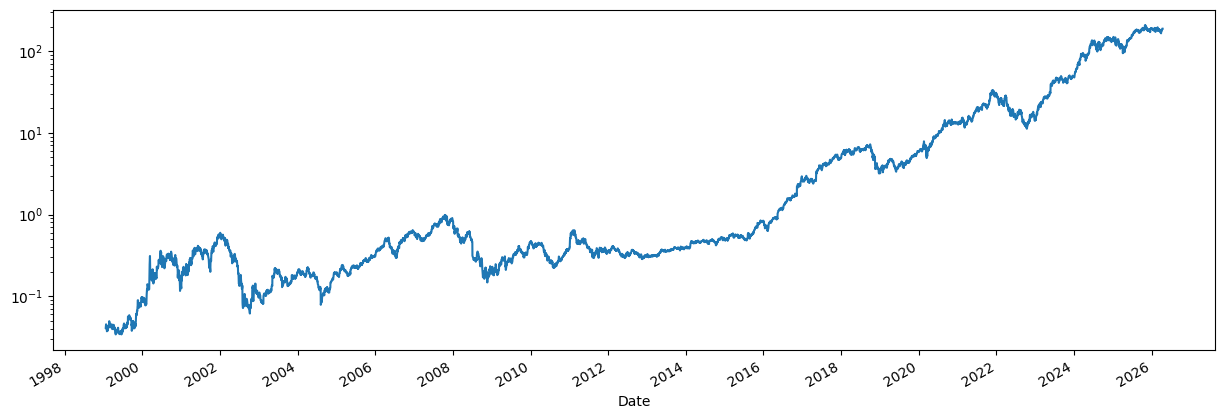

In [15]:
df['Close'].plot(figsize=(15,5))
plt.yscale('log')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base = 2))

plt.show()

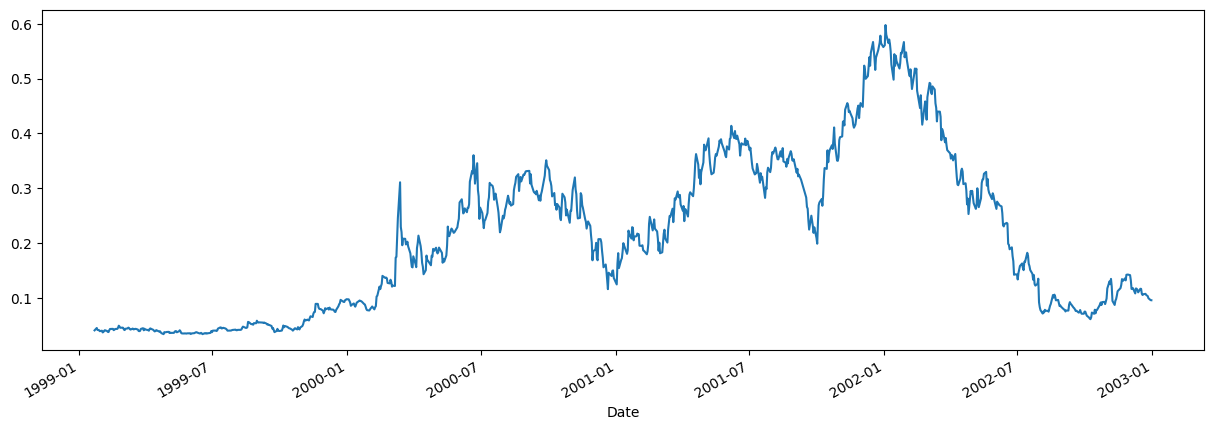

In [16]:
df['1999':'2002']['Close'].plot(figsize = (15, 5))
ax = plt.gca()
#ax.xaxis.set_major_locator(mdates.YearLocator(base = 1))
plt.show()

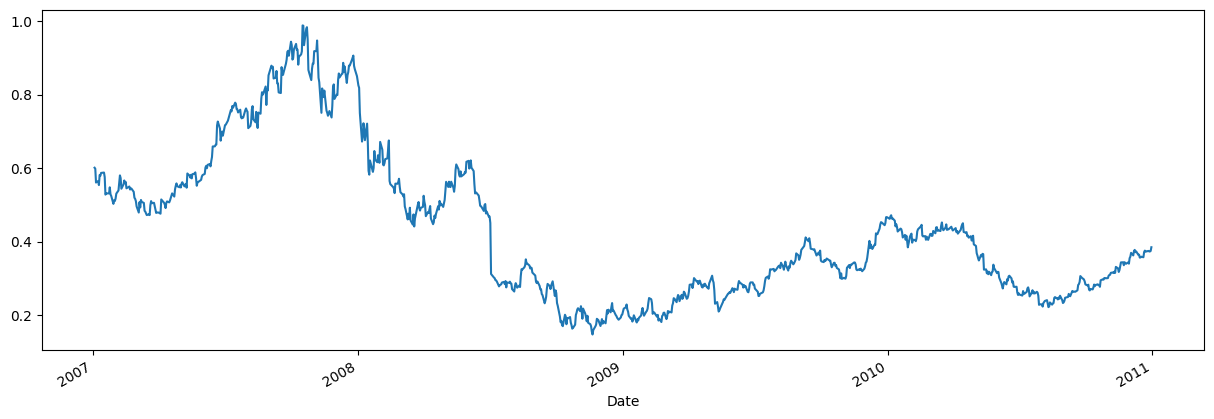

In [17]:
# 2008 crisis 
df['2007':'2010']['Close'].plot(figsize=(15,5))
#plt.yscale('log')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base = 1))

plt.show()

In [18]:
(df['Close'] == df['Adj Close']).value_counts()

False    6824
True       23
Name: count, dtype: int64

In [19]:
df['Close'].pct_change().sort_values() #1999-01-22 is NaN because its trying to inc or dec based of previous change

Date
2004-08-06   -0.352336
2002-07-31   -0.317511
2008-07-03   -0.307266
2000-03-14   -0.262146
2002-11-08   -0.219241
                ...   
2016-11-11    0.298067
2001-01-03    0.306886
2003-05-09    0.330636
2000-03-07    0.424148
1999-01-22         NaN
Name: Close, Length: 6847, dtype: float64

Test the data on Adj Close because it contains split and dividend. It is also different from close. Adj Close reflect actual value change. close wont tell the full story and it will look like the company is losing money when a split occurs. 


Checked df.head() for open, close and adjust close and it looks open is adjust scale like adj close. open, low, high and adj are scaled which means we drop close since its raw and doesnt have split and dividend scale. 

In [20]:
df = df.drop(columns = ['Close'])
df.head()

,Adj Close,High,Low,Open,Volume
Date,,,,,
1999-01-22,0.037603,0.048828,0.038802,0.043750,2714688000
1999-01-25,0.041542,0.045833,0.041016,0.044271,510480000
1999-01-26,0.038319,0.046745,0.041146,0.045833,343200000
1999-01-27,0.038200,0.042969,0.039583,0.041927,244368000
1999-01-28,0.038080,0.041927,0.041276,0.041667,227520000


## Setting the up and down system to predict tomorrows price

In [21]:
df['shift_adj_close'] = df['Adj Close'].shift(-1)
#(Quick way to remember it: shift(1) = "look backward, bring yesterday's value into today" / shift(-1) = "look forward, bring tomorrow's value into today.")
df.head()

,Adj Close,High,Low,Open,Volume,shift_adj_close
Date,,,,,,
1999-01-22,0.037603,0.048828,0.038802,0.043750,2714688000,0.041542
1999-01-25,0.041542,0.045833,0.041016,0.044271,510480000,0.038319
1999-01-26,0.038319,0.046745,0.041146,0.045833,343200000,0.038200
1999-01-27,0.038200,0.042969,0.039583,0.041927,244368000,0.038080
1999-01-28,0.038080,0.041927,0.041276,0.041667,227520000,0.036289


In [22]:
df['target'] = (df['shift_adj_close'] > df['Adj Close']).astype(int)
df.head()
df.tail()

,Adj Close,High,Low,Open,Volume,shift_adj_close,target
Date,,,,,,,
2026-04-07,178.100006,178.229996,173.660004,175.729996,132534900,182.080002,1
2026-04-08,182.080002,185.259995,180.300003,184.500000,147732700,183.910004,1
2026-04-09,183.910004,184.080002,180.619995,181.839996,116428500,188.630005,1
2026-04-10,188.630005,190.000000,184.300003,184.309998,160099500,188.335007,0
2026-04-13,188.335007,189.649994,185.740005,186.020004,58916279,NaN,0


In [23]:
df = df.dropna(axis = 0)
df.isna().sum()


Adj Close          0
High               0
Low                0
Open               0
Volume             0
shift_adj_close    0
target             0
dtype: int64

In [24]:
df['target'].value_counts()

target
1    3540
0    3306
Name: count, dtype: int64

3540 + 3306 = 6846, 3540 / 6846 so about 51.7% would be our baseline accuracy for this model

In [25]:
df = df.drop(columns=['shift_adj_close']) # dropping this column for feature engineering and also for my model doesnt cheat

In [26]:
df.columns

Index(['Adj Close', 'High', 'Low', 'Open', 'Volume', 'target'], dtype='str')

## Feature Engineering

In [27]:
# Basic Price Feature
df['High-low-range'] = df['High'] - df['Low']
df['Price-Change'] = df['Adj Close'] - df['Open']
df['Open-Close-ratio'] = df['Adj Close'] / df['Open']
df['High-Low-ratio'] = df['High'] / df['Low']

# lag feature
df['lag_1'] = df['Adj Close'].shift(1)
df['lag_3'] = df['Adj Close'].shift(3) # not meaningful 
df['lag_7'] = df['Adj Close'].shift(7)
# df['lag_30'] = df['Adj Close'].shift(30) 


#rolling average 
#df['roll_avg_2'] = df['Adj Close'].rolling(2).mean() could be meaningful
df['roll_avg_5'] = df['Adj Close'].rolling(5).mean() # business days
df['roll_avg_7'] = df['Adj Close'].rolling(7).mean() # whole week
df['roll_avg_50'] = df['Adj Close'].rolling(50).mean() # quarterly


In [28]:
df.head(50)
df.isna().sum()
df = df.dropna()
df.shape
df.columns

Index(['Adj Close', 'High', 'Low', 'Open', 'Volume', 'target',
       'High-low-range', 'Price-Change', 'Open-Close-ratio', 'High-Low-ratio',
       'lag_1', 'lag_3', 'lag_7', 'roll_avg_5', 'roll_avg_7', 'roll_avg_50'],
      dtype='str')

## Model

In [29]:
# the beginning of data centers
features_col = ['Adj Close', 'High', 'Low', 'Open', 'Volume', 'High-low-range', 'Price-Change', 'Open-Close-ratio', 'High-Low-ratio',
       'lag_1', 'lag_3', 'lag_7', 'roll_avg_5', 'roll_avg_7', 'roll_avg_50']
X = df[features_col]
y = df['target']
#print(len(X['1999':'2015-05']))
#print(len(X['2015-05':df.index.max()])) # test should be around 2019

cutoff = '2021-01-01'
X_train = X[:cutoff]
X_test = X[cutoff:]
y_train = y[:cutoff]
y_test = y[cutoff:]

#print(len(X_train), len(y_test))
#print(len(X_train) / (len(X_train) + len(X_test))) # train percent

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print('accuracy:', acc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy: 0.5215419501133787
[[151 463]
 [170 539]]
              precision    recall  f1-score   support

           0       0.47      0.25      0.32       614
           1       0.54      0.76      0.63       709

    accuracy                           0.52      1323
   macro avg       0.50      0.50      0.48      1323
weighted avg       0.51      0.52      0.49      1323



In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelRF = RandomForestClassifier(random_state=42)
modelRF.fit(X_train_scaled, y_train)

y_pred = modelRF.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print('accuracy:', acc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy: 0.47316704459561604
[[587  27]
 [670  39]]
              precision    recall  f1-score   support

           0       0.47      0.96      0.63       614
           1       0.59      0.06      0.10       709

    accuracy                           0.47      1323
   macro avg       0.53      0.51      0.36      1323
weighted avg       0.53      0.47      0.35      1323



Logistic regression gave a better accuracy score over random forest classifer

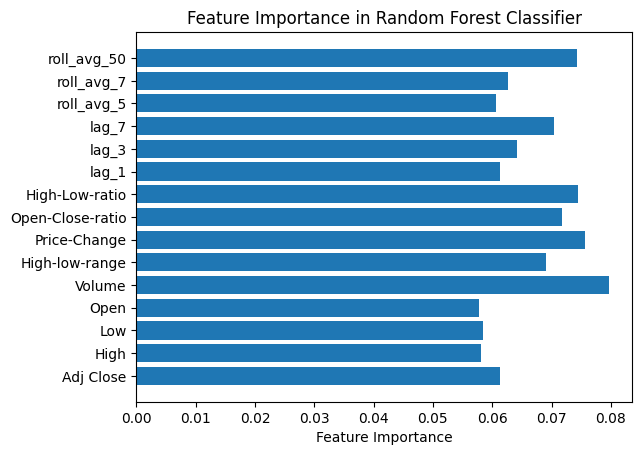

In [31]:
feature_importances = modelRF.feature_importances_

plt.barh(features_col, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

no feature here strongly predicts next-day direction, though Volume/Price-Change/High-Low-ratio contribute marginally more than others.

## Tuning

In [40]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param = [{'penalty': ['l1', 'l2'], 
          'C': [0.01, 0.1, 0.8, 1, 10],
          'solver': ['liblinear'],
        },
        {'penalty': ['l2', None],
         'C': [0.01, 0.1, 0.8, 1, 10],
         'solver': ['lbfgs', 'newton-cg']
        }
]

tscv = TimeSeriesSplit(n_splits=5)

tune_model = GridSearchCV(model, param_grid= param, cv = tscv, verbose= 0,n_jobs = -1)
best_model = tune_model.fit(X_train_scaled, y_train)
print(best_model.best_params_)
print(f'Accuracy - : {best_model.score(X_test_scaled,y_test):.3f}')

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy - : 0.528


C:\Users\Hottr\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Hottr\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
